# GenRec Hint Cascade Analysis 3: Local Hypothesis Testing

这份 notebook 使用本地 research bundle，不再依赖远端路径。目标不是重复做 summary，而是围绕更明确的假设做逐步验证：

1. `Small subtree` 是否比 `low-frequency token` 更能解释 deep hint。
2. `hisTitle2sid` 比 `sid` 更难，是否在控制 tree / frequency 后仍然成立。
3. 困难样本是否集中在一小批共享 branch 上，而不是均匀分散。
4. `Local imbalance` 到底是独立信号，还是只是小 subtree 的 proxy。
5. sequence feature 是主因，还是只剩下很弱的 residual effect。

所有 plot 的 title / axis / legend 都保持英文，中文解释留在 markdown 里。

## Roadmap

建议按下面顺序运行：

1. Load local bundle and sanity checks
2. Task difficulty baseline
3. Hypothesis A: subtree size dominates
4. Hypothesis B: task gap after controlling for frequency/subtree
5. Hypothesis C: branch hotspot overlap
6. Hypothesis D: imbalance vs subtree disentangling
7. Hypothesis E: sequence residual effect
8. Hard-case gallery and exports

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
REPO_ROOT = Path("/Users/fanghaotian/Desktop/src/GenRec")
BUNDLE_ROOT = REPO_ROOT / "output/local-research-bundles/instruments_grec_hint_research_bundle"
GENREC_BUNDLE_ROOT = BUNDLE_ROOT / "GenRec"
RAW_BUNDLE_ROOT = BUNDLE_ROOT / "raw_data"

DIFFICULTY_TABLE_PATH = (
    GENREC_BUNDLE_ROOT
    / "output/jupyter-notebook/genrec-hint-cascade-artifacts/instruments_grec_beam16_hint_difficulty_table.csv"
)
SUMMARY_PATH = GENREC_BUNDLE_ROOT / "temp/rl_beam_hint/instruments_grec_beam_hint_cascade_20260314_summary.json"
DETAILS_PATH = GENREC_BUNDLE_ROOT / "temp/rl_beam_hint/instruments_grec_beam_hint_cascade_20260314_details.json"
TRAIN_JSON_PATH = (
    GENREC_BUNDLE_ROOT
    / "data/Instruments_grec_index_emb-qwen3-embedding-4B_rq4_cb256-256-256-256_dsInstruments_ridFeb-10-2026-05-40-47/rl/train.json"
)
INDEX_JSON_PATH = (
    GENREC_BUNDLE_ROOT
    / "data/Instruments_grec_index_emb-qwen3-embedding-4B_rq4_cb256-256-256-256_dsInstruments_ridFeb-10-2026-05-40-47/id2sid.json"
)
INTER_JSON_PATH = RAW_BUNDLE_ROOT / "Instruments/Instruments.inter.json"
ITEM_JSON_PATH = RAW_BUNDLE_ROOT / "Instruments/Instruments.item.json"
EXPORT_DIR = REPO_ROOT / "output/jupyter-notebook/genrec-hint-cascade-artifacts"

required_paths = [
    DIFFICULTY_TABLE_PATH,
    SUMMARY_PATH,
    DETAILS_PATH,
    TRAIN_JSON_PATH,
    INDEX_JSON_PATH,
    INTER_JSON_PATH,
    ITEM_JSON_PATH,
]

pd.DataFrame({"path": [str(path) for path in required_paths], "exists": [path.exists() for path in required_paths]})

,path,exists
0,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True
1,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True
2,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True
3,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True
4,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True
5,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True
6,/Users/fanghaotian/Desktop/src/GenRec/output/l...,True


In [3]:
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing local research files:" + "\n".join(missing_paths))

sample_df = pd.read_csv(DIFFICULTY_TABLE_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
details = json.loads(DETAILS_PATH.read_text(encoding="utf-8"))
train_samples = json.loads(TRAIN_JSON_PATH.read_text(encoding="utf-8"))
index_payload = json.loads(INDEX_JSON_PATH.read_text(encoding="utf-8"))
inter_payload = json.loads(INTER_JSON_PATH.read_text(encoding="utf-8"))
items_payload = json.loads(ITEM_JSON_PATH.read_text(encoding="utf-8"))

numeric_columns = [
    "sample_id",
    "source_index",
    "first_hit_depth",
    "effective_hint_depth",
    "required_train_token_count",
    "required_train_token_share",
    "required_task_token_share",
    "required_task_parent_child_share",
    "required_tree_subtree_size",
    "required_tree_child_share",
    "required_tree_child_rank",
    "required_tree_sibling_count",
    "required_tree_parent_entropy",
    "required_tree_parent_gini",
    "required_tree_parent_max_child_share",
    "seq_train_seq_len",
    "seq_history_len",
    "seq_target_pos_in_train",
    "seq_target_pos_ratio",
    "seq_target_from_end",
    "seq_target_repeats_last_item",
]
for column in numeric_columns:
    if column in sample_df.columns:
        sample_df[column] = pd.to_numeric(sample_df[column], errors="coerce")

sample_df["is_base_hit"] = sample_df["effective_hint_depth"] == 0
sample_df["is_hinted"] = sample_df["effective_hint_depth"].between(1, 3)
sample_df["is_deep_hint"] = sample_df["effective_hint_depth"] >= 2
sample_df["is_unsolved"] = sample_df["hint_bucket"].astype(str).eq("unsolved_after_hint_3")

sample_df[["sample_id", "task_label", "hint_bucket", "required_sid_token", "required_tree_subtree_size"]].head(12)

,sample_id,task_label,hint_bucket,required_sid_token,required_tree_subtree_size
0,0,sid,base,NaN,NaN
1,1,sid,hint_2,<b_122>,4.0
2,2,sid,hint_2,<b_134>,4.0
3,4,sid,hint_1,<a_77>,107.0
4,5,sid,hint_1,<a_199>,129.0
5,6,sid,hint_2,<b_157>,10.0
6,7,sid,hint_1,<a_150>,187.0
7,8,sid,hint_2,<b_156>,8.0
8,9,sid,hint_1,<a_234>,161.0
9,10,sid,hint_2,<b_94>,6.0


## Baseline: Task Difficulty

先把任务层面的差异钉住，后面所有控制变量分析都围绕这个 baseline 展开。

,task_label,sample_count,base_hit_rate,need_hint_rate,deep_hint_rate,final_unsolved_rate
0,hisTitle2sid,10000,0.086900,0.913000,0.612400,0.000100
1,sid,84890,0.282519,0.717411,0.327047,0.000071
2,title_desc2sid,11551,0.718120,0.281534,0.229504,0.000346


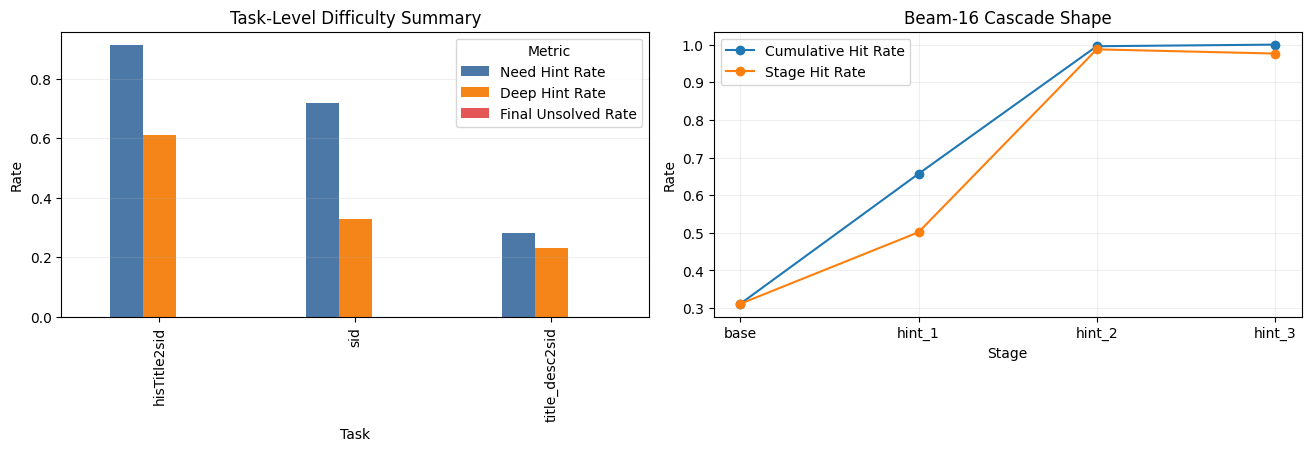

In [4]:
task_overview = (
    sample_df.groupby("task_label", observed=False)
    .agg(
        sample_count=("sample_id", "size"),
        base_hit_rate=("is_base_hit", "mean"),
        need_hint_rate=("is_hinted", "mean"),
        deep_hint_rate=("is_deep_hint", "mean"),
        final_unsolved_rate=("is_unsolved", "mean"),
    )
    .reset_index()
)

display(task_overview)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)
plot_frame = task_overview.set_index("task_label")[["need_hint_rate", "deep_hint_rate", "final_unsolved_rate"]]
plot_frame.rename(
    columns={
        "need_hint_rate": "Need Hint Rate",
        "deep_hint_rate": "Deep Hint Rate",
        "final_unsolved_rate": "Final Unsolved Rate",
    }
).plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#E45756"])
axes[0].set_title("Task-Level Difficulty Summary")
axes[0].set_xlabel("Task")
axes[0].set_ylabel("Rate")
axes[0].legend(title="Metric")
axes[0].grid(alpha=0.2, axis="y")

stage_frame = pd.DataFrame(
    [
        {
            "beam_size": int(beam_size),
            "stage_name": stage_name,
            "stage_hit_rate": stage_payload["stage_rule_hit_sample_rate_within_input"],
            "cumulative_hit_rate": stage_payload["cumulative_rule_hit_sample_rate"],
        }
        for beam_size, beam_payload in summary["results"].items()
        for stage_name, stage_payload in beam_payload["stages"].items()
    ]
).sort_values(["beam_size", "stage_name"])
focus_stage_frame = stage_frame[stage_frame["beam_size"] == 16]
axes[1].plot(
    focus_stage_frame["stage_name"], focus_stage_frame["cumulative_hit_rate"], marker="o", label="Cumulative Hit Rate"
)
axes[1].plot(focus_stage_frame["stage_name"], focus_stage_frame["stage_hit_rate"], marker="o", label="Stage Hit Rate")
axes[1].set_title("Beam-16 Cascade Shape")
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Rate")
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.show()

## Hypothesis A: Small Subtree Dominates Over Low Token Frequency

先不看 task，只回答一个更强的问题：`deep hint` 更像由 `required_tree_subtree_size` 驱动，还是由 `required_train_token_count` 驱动。

In [5]:
hinted_df = sample_df[sample_df["is_hinted"]].copy()

for feature in ["required_train_token_count", "required_tree_subtree_size", "required_tree_parent_max_child_share"]:
    ranked = hinted_df[feature].rank(method="first")
    hinted_df[f"{feature}_quartile"] = pd.qcut(ranked, 4, labels=["Q1", "Q2", "Q3", "Q4"])

feature_rate_rows = []
for feature in ["required_train_token_count", "required_tree_subtree_size", "required_tree_parent_max_child_share"]:
    tmp = (
        hinted_df.groupby(["task_label", f"{feature}_quartile"], observed=False)
        .agg(
            sample_count=("sample_id", "size"),
            deep_hint_rate=("is_deep_hint", "mean"),
            mean_hint_depth=("effective_hint_depth", "mean"),
        )
        .reset_index()
        .rename(columns={f"{feature}_quartile": "quartile"})
    )
    tmp["feature"] = feature
    feature_rate_rows.append(tmp)
feature_rate_df = pd.concat(feature_rate_rows, ignore_index=True)
display(feature_rate_df)

,task_label,quartile,sample_count,deep_hint_rate,mean_hint_depth,feature
0,hisTitle2sid,Q1,2783,0.988142,2.000359,required_train_token_count
1,hisTitle2sid,Q2,2855,0.924343,1.939405,required_train_token_count
2,hisTitle2sid,Q3,1671,0.361460,1.361460,required_train_token_count
3,hisTitle2sid,Q4,1821,0.071389,1.071389,required_train_token_count
4,sid,Q1,14119,0.982223,1.991784,required_train_token_count
5,sid,Q2,14372,0.819649,1.830017,required_train_token_count
6,sid,Q3,16160,0.117450,1.117698,required_train_token_count
7,sid,Q4,16250,0.012985,1.012985,required_train_token_count
8,title_desc2sid,Q1,1419,0.990839,2.022551,required_train_token_count
9,title_desc2sid,Q2,1094,0.938757,1.974406,required_train_token_count


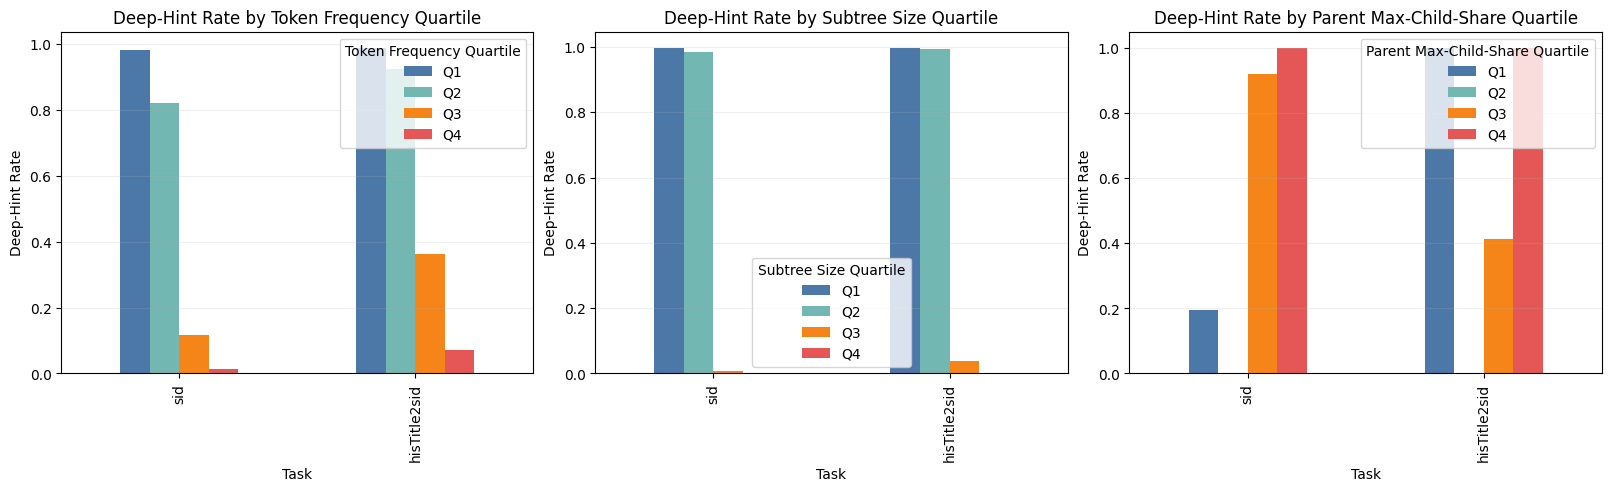

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
features = [
    ("required_train_token_count", "Token Frequency Quartile"),
    ("required_tree_subtree_size", "Subtree Size Quartile"),
    ("required_tree_parent_max_child_share", "Parent Max-Child-Share Quartile"),
]
for axis, (feature, axis_label) in zip(axes, features):
    subset = feature_rate_df[feature_rate_df["feature"] == feature]
    pivot = subset.pivot(index="task_label", columns="quartile", values="deep_hint_rate").reindex(
        ["sid", "hisTitle2sid"]
    )
    pivot.plot(kind="bar", ax=axis, color=["#4C78A8", "#72B7B2", "#F58518", "#E45756"])
    axis.set_title(f"Deep-Hint Rate by {axis_label}")
    axis.set_xlabel("Task")
    axis.set_ylabel("Deep-Hint Rate")
    axis.legend(title=axis_label)
    axis.grid(alpha=0.2, axis="y")
plt.show()

这里的重点不是哪条曲线更“好看”，而是哪个特征的四分位切分对 deep-hint rate 的分离最强。通常如果 `subtree_size` 的 Q1/Q4 分离远大于 `token_count`，就说明树结构比 token 稀疏度更主导。

## Hypothesis B: Does the Task Gap Survive After Controlling for Frequency and Subtree Size?

如果 `hisTitle2sid` 只是因为落到了更差的 token / subtree 上，那么在相同 bin 内它和 `sid` 的 deep-hint rate 应该接近。反之，如果在 matched bins 内差距还在，就说明 task-formulation 本身也在起作用。

In [7]:
matched_df = hinted_df.copy()
matched_df["freq_bin"] = matched_df["required_train_token_count_quartile"]
matched_df["subtree_bin"] = matched_df["required_tree_subtree_size_quartile"]

matched_summary = (
    matched_df.groupby(["task_label", "freq_bin", "subtree_bin"], observed=False)
    .agg(
        sample_count=("sample_id", "size"),
        deep_hint_rate=("is_deep_hint", "mean"),
        mean_hint_depth=("effective_hint_depth", "mean"),
    )
    .reset_index()
)
display(matched_summary.head(20))

,task_label,freq_bin,subtree_bin,sample_count,deep_hint_rate,mean_hint_depth
0,hisTitle2sid,Q1,Q1,1515,0.994059,2.015182
1,hisTitle2sid,Q1,Q2,1258,0.980922,1.982512
2,hisTitle2sid,Q1,Q3,10,1.000000,2.000000
3,hisTitle2sid,Q1,Q4,0,NaN,NaN
4,hisTitle2sid,Q2,Q1,1072,1.000000,2.021455
5,hisTitle2sid,Q2,Q2,1520,1.000000,2.013158
6,hisTitle2sid,Q2,Q3,263,0.178707,1.178707
7,hisTitle2sid,Q2,Q4,0,NaN,NaN
8,hisTitle2sid,Q3,Q1,217,1.000000,2.000000
9,hisTitle2sid,Q3,Q2,387,1.000000,2.000000


In [8]:
comparison_rows = []
for (freq_bin, subtree_bin), pair in matched_summary.groupby(["freq_bin", "subtree_bin"], observed=False):
    row = {"freq_bin": freq_bin, "subtree_bin": subtree_bin}
    for task_label in ["sid", "hisTitle2sid"]:
        task_row = pair[pair["task_label"] == task_label]
        if task_row.empty:
            row[f"{task_label}_sample_count"] = 0
            row[f"{task_label}_deep_hint_rate"] = None
        else:
            row[f"{task_label}_sample_count"] = int(task_row["sample_count"].iloc[0])
            row[f"{task_label}_deep_hint_rate"] = float(task_row["deep_hint_rate"].iloc[0])
    if row["sid_deep_hint_rate"] is not None and row["hisTitle2sid_deep_hint_rate"] is not None:
        row["task_gap"] = row["hisTitle2sid_deep_hint_rate"] - row["sid_deep_hint_rate"]
    else:
        row["task_gap"] = None
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values("task_gap", ascending=False).head(20))

,freq_bin,subtree_bin,sid_sample_count,sid_deep_hint_rate,hisTitle2sid_sample_count,hisTitle2sid_deep_hint_rate,task_gap
6,Q2,Q3,2617,0.009553,263,0.178707,0.169154
1,Q1,Q2,5757,0.966128,1258,0.980922,0.014794
0,Q1,Q1,8282,0.993238,1515,0.994059,0.000821
2,Q1,Q3,80,1.000000,10,1.000000,0.000000
4,Q2,Q1,5048,1.000000,1072,1.000000,0.000000
5,Q2,Q2,6707,1.000000,1520,1.000000,0.000000
8,Q3,Q1,723,1.000000,217,1.000000,0.000000
9,Q3,Q2,1175,1.000000,387,1.000000,0.000000
10,Q3,Q3,11107,0.000000,896,0.000000,0.000000
11,Q3,Q4,3155,0.000000,171,0.000000,0.000000


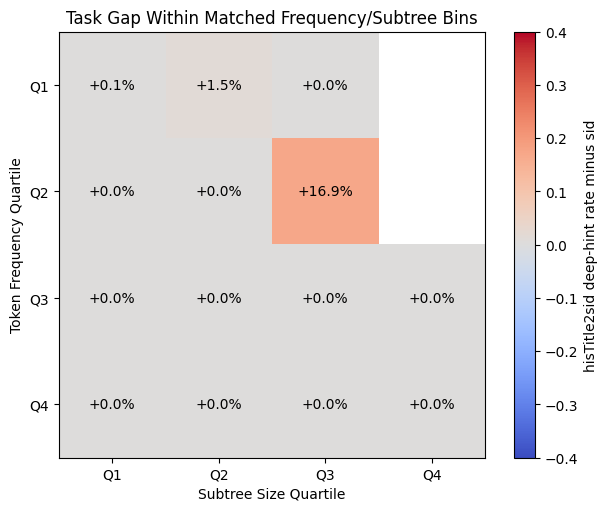

In [9]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
heat = comparison_df.pivot(index="freq_bin", columns="subtree_bin", values="task_gap")
im = ax.imshow(heat.values, cmap="coolwarm", vmin=-0.4, vmax=0.4)
ax.set_title("Task Gap Within Matched Frequency/Subtree Bins")
ax.set_xlabel("Subtree Size Quartile")
ax.set_ylabel("Token Frequency Quartile")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(list(heat.columns))
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(list(heat.index))
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.iloc[i, j]
        ax.text(j, i, "" if pd.isna(value) else f"{value:+.1%}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="hisTitle2sid deep-hint rate minus sid")
plt.show()

## Hypothesis C: Hard Samples Concentrate on Shared Branch Hotspots

这里不看均值，而是直接看 branch hotspot：哪些 `required_sid_parent_prefix` 在 `deep hint` / `unsolved` 子集里过度集中；而且这些 hotspot 是否在 `sid` 和 `hisTitle2sid` 之间共享。

In [10]:
def build_lift_table(
    frame: pd.DataFrame, group_column: str, focus_mask: pd.Series, baseline_mask: pd.Series, min_focus_count: int = 5
) -> pd.DataFrame:
    focus_counts = (
        frame.loc[focus_mask & frame[group_column].notna(), group_column].value_counts().rename("focus_count")
    )
    baseline_counts = (
        frame.loc[baseline_mask & frame[group_column].notna(), group_column].value_counts().rename("baseline_count")
    )
    merged = pd.concat([focus_counts, baseline_counts], axis=1).fillna(0.0)
    if merged.empty:
        return pd.DataFrame(
            columns=[group_column, "focus_count", "baseline_count", "focus_share", "baseline_share", "share_lift"]
        )
    merged = merged[merged["focus_count"] >= min_focus_count].copy()
    if merged.empty:
        return pd.DataFrame(
            columns=[group_column, "focus_count", "baseline_count", "focus_share", "baseline_share", "share_lift"]
        )
    merged["focus_share"] = merged["focus_count"] / merged["focus_count"].sum()
    merged["baseline_share"] = merged["baseline_count"] / merged["baseline_count"].sum()
    merged["share_lift"] = merged["focus_share"] / merged["baseline_share"].replace(0, pd.NA)
    return merged.sort_values(["share_lift", "focus_count"], ascending=[False, False]).reset_index(names=group_column)


sid_prefix_lift = build_lift_table(
    hinted_df[hinted_df["task_label"] == "sid"],
    "required_sid_parent_prefix",
    hinted_df[hinted_df["task_label"] == "sid"]["is_deep_hint"],
    hinted_df[hinted_df["task_label"] == "sid"]["is_hinted"],
    min_focus_count=20,
)
his_prefix_lift = build_lift_table(
    hinted_df[hinted_df["task_label"] == "hisTitle2sid"],
    "required_sid_parent_prefix",
    hinted_df[hinted_df["task_label"] == "hisTitle2sid"]["is_deep_hint"],
    hinted_df[hinted_df["task_label"] == "hisTitle2sid"]["is_hinted"],
    min_focus_count=10,
)

display(sid_prefix_lift.head(15))
display(his_prefix_lift.head(15))

,required_sid_parent_prefix,focus_count,baseline_count,focus_share,baseline_share,share_lift
0,<a_194>,2346.0,2346,0.084837,0.084837,1.0
1,<a_157>,2234.0,2234,0.080787,0.080787,1.0
2,<a_241>,1856.0,1856,0.067117,0.067117,1.0
3,<a_145>,1636.0,1636,0.059162,0.059162,1.0
4,<a_125>,1617.0,1617,0.058475,0.058475,1.0
5,<a_253>,1460.0,1460,0.052797,0.052797,1.0
6,<a_65>,1411.0,1411,0.051025,0.051025,1.0
7,<a_198>,1297.0,1297,0.046903,0.046903,1.0
8,<a_146>,1230.0,1230,0.044480,0.044480,1.0
9,<a_19>,1037.0,1037,0.037500,0.037500,1.0


,required_sid_parent_prefix,focus_count,baseline_count,focus_share,baseline_share,share_lift
0,<a_194>,474.0,474,0.078205,0.078205,1.0
1,<a_241>,449.0,449,0.074080,0.074080,1.0
2,<a_125>,367.0,367,0.060551,0.060551,1.0
3,<a_253>,348.0,348,0.057416,0.057416,1.0
4,<a_65>,314.0,314,0.051807,0.051807,1.0
5,<a_157>,309.0,309,0.050982,0.050982,1.0
6,<a_145>,306.0,306,0.050487,0.050487,1.0
7,<a_170>,234.0,234,0.038607,0.038607,1.0
8,<a_105>,223.0,223,0.036793,0.036793,1.0
9,<a_198>,219.0,219,0.036133,0.036133,1.0


In [11]:
sid_top = set(sid_prefix_lift.head(20)["required_sid_parent_prefix"])
his_top = set(his_prefix_lift.head(20)["required_sid_parent_prefix"])
overlap = sorted(sid_top & his_top)

pd.Series(
    {
        "sid_top20_prefix_count": len(sid_top),
        "his_top20_prefix_count": len(his_top),
        "overlap_count": len(overlap),
        "jaccard": len(overlap) / len(sid_top | his_top) if (sid_top | his_top) else 0.0,
        "overlap_prefixes": overlap,
    }
)

sid_top20_prefix_count                                                   20
his_top20_prefix_count                                                   20
overlap_count                                                            18
jaccard                                                            0.818182
overlap_prefixes          [<a_105>, <a_125>, <a_144>, <a_145>, <a_146>, ...
dtype: object

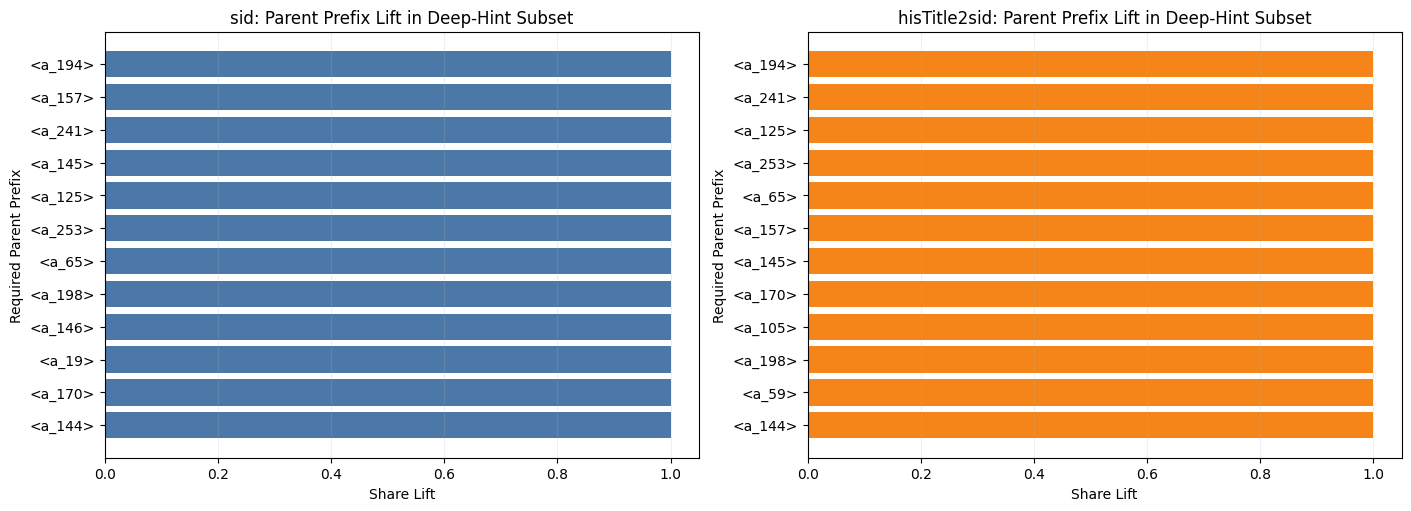

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, lift_df, task_label, color in [
    (axes[0], sid_prefix_lift, "sid", "#4C78A8"),
    (axes[1], his_prefix_lift, "hisTitle2sid", "#F58518"),
]:
    top = lift_df.head(12).iloc[::-1]
    axis.barh(top["required_sid_parent_prefix"], top["share_lift"], color=color)
    axis.set_title(f"{task_label}: Parent Prefix Lift in Deep-Hint Subset")
    axis.set_xlabel("Share Lift")
    axis.set_ylabel("Required Parent Prefix")
    axis.grid(alpha=0.2, axis="x")
plt.show()

## Hypothesis D: Is Imbalance an Independent Signal, or Just a Proxy for Small Subtrees?

`required_tree_parent_max_child_share` 和 `required_tree_parent_entropy` 看起来像结构难度，但它们可能只是 `small subtree` 的 proxy。这里先按 subtree quartile 切开，再看 imbalance 是否还保留明显差异。

In [13]:
imbalance_control = (
    hinted_df.groupby(["required_tree_subtree_size_quartile", "task_label"], observed=False)
    .agg(
        sample_count=("sample_id", "size"),
        mean_parent_max_child_share=("required_tree_parent_max_child_share", "mean"),
        mean_parent_entropy=("required_tree_parent_entropy", "mean"),
        deep_hint_rate=("is_deep_hint", "mean"),
    )
    .reset_index()
)
display(imbalance_control)

,required_tree_subtree_size_quartile,task_label,sample_count,mean_parent_max_child_share,mean_parent_entropy,deep_hint_rate
0,Q1,hisTitle2sid,2906,0.083440,0.915693,0.996903
1,Q1,sid,14188,0.080435,0.914901,0.996053
2,Q1,title_desc2sid,1227,0.086286,0.915500,0.999185
3,Q2,hisTitle2sid,3193,0.084211,0.905498,0.992484
4,Q2,sid,13715,0.083799,0.902945,0.985782
5,Q2,title_desc2sid,1413,0.085347,0.905836,0.991507
6,Q3,hisTitle2sid,1478,0.062748,0.929659,0.038566
7,Q3,sid,16502,0.061849,0.930936,0.006363
8,Q3,title_desc2sid,340,0.062649,0.929416,0.058824
9,Q4,hisTitle2sid,1553,0.061600,0.931237,0.000000


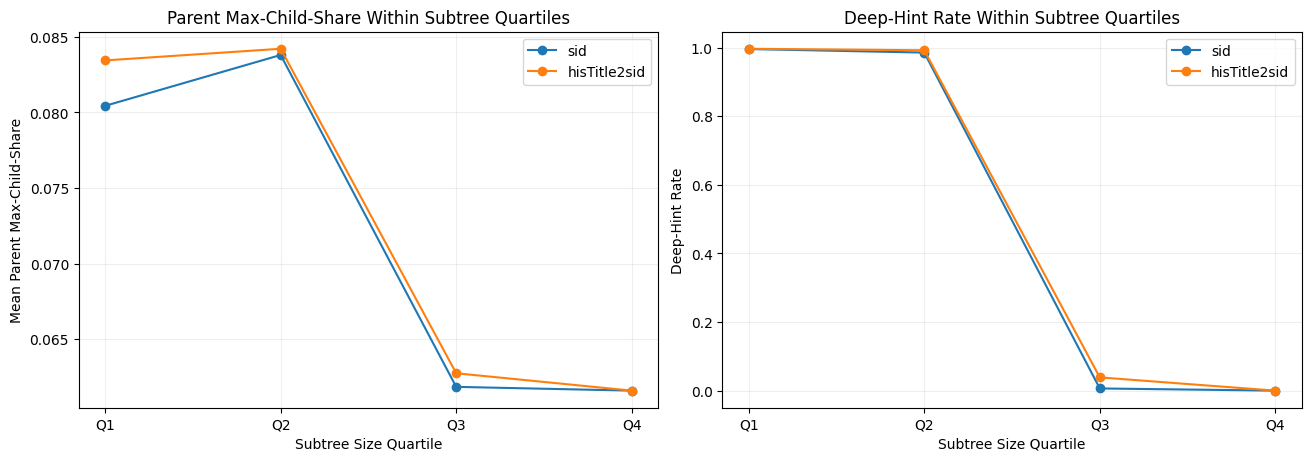

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for task_label in ["sid", "hisTitle2sid"]:
    task_frame = imbalance_control[imbalance_control["task_label"] == task_label]
    axes[0].plot(
        task_frame["required_tree_subtree_size_quartile"].astype(str),
        task_frame["mean_parent_max_child_share"],
        marker="o",
        label=task_label,
    )
    axes[1].plot(
        task_frame["required_tree_subtree_size_quartile"].astype(str),
        task_frame["deep_hint_rate"],
        marker="o",
        label=task_label,
    )

axes[0].set_title("Parent Max-Child-Share Within Subtree Quartiles")
axes[0].set_xlabel("Subtree Size Quartile")
axes[0].set_ylabel("Mean Parent Max-Child-Share")
axes[1].set_title("Deep-Hint Rate Within Subtree Quartiles")
axes[1].set_xlabel("Subtree Size Quartile")
axes[1].set_ylabel("Deep-Hint Rate")
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend()
plt.show()

## Hypothesis E: Sequence Features Are Residual, Not Primary

前面已经看到 tree / frequency 信号很强。这里看 sequence feature 在控制 `subtree quartile` 之后是否还保留明显梯度。

In [15]:
sequence_df = hinted_df[hinted_df["task_label"].isin(["sid", "hisTitle2sid"])].copy()
for feature in ["seq_history_len", "seq_target_pos_ratio"]:
    ranked = sequence_df[feature].rank(method="first")
    sequence_df[f"{feature}_quartile"] = pd.qcut(ranked, 4, labels=["Q1", "Q2", "Q3", "Q4"])

sequence_control = (
    sequence_df.groupby(
        ["task_label", "required_tree_subtree_size_quartile", "seq_history_len_quartile"], observed=False
    )
    .agg(
        sample_count=("sample_id", "size"),
        deep_hint_rate=("is_deep_hint", "mean"),
    )
    .reset_index()
)
display(sequence_control.head(20))

,task_label,required_tree_subtree_size_quartile,seq_history_len_quartile,sample_count,deep_hint_rate
0,hisTitle2sid,Q1,Q1,397,0.997481
1,hisTitle2sid,Q1,Q2,388,0.997423
2,hisTitle2sid,Q1,Q3,859,0.998836
3,hisTitle2sid,Q1,Q4,1262,0.995246
4,hisTitle2sid,Q2,Q1,421,0.990499
5,hisTitle2sid,Q2,Q2,418,0.995215
6,hisTitle2sid,Q2,Q3,971,0.994851
7,hisTitle2sid,Q2,Q4,1383,0.990600
8,hisTitle2sid,Q3,Q1,186,0.032258
9,hisTitle2sid,Q3,Q2,196,0.030612


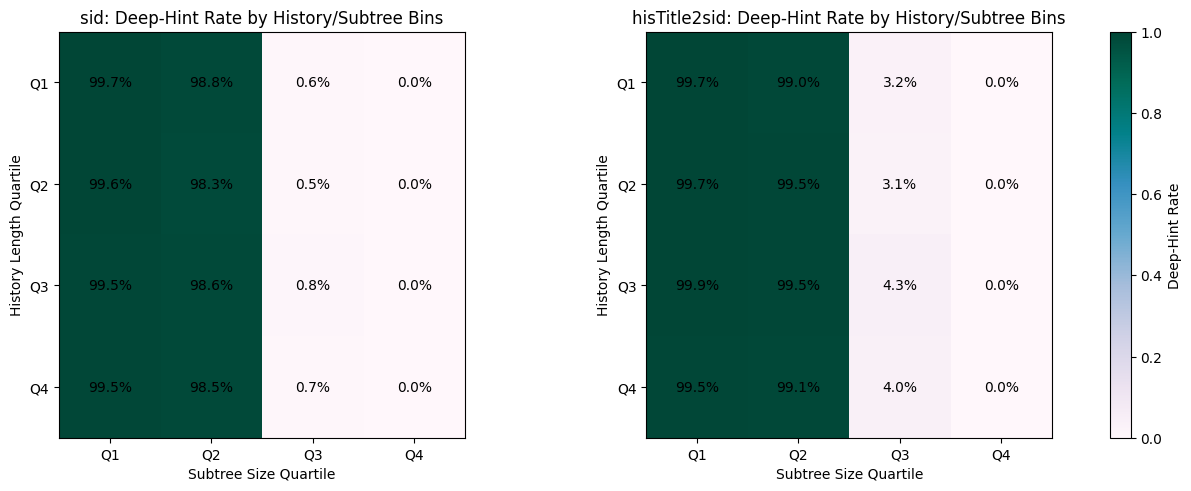

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for axis, task_label in zip(axes, ["sid", "hisTitle2sid"]):
    subset = sequence_control[sequence_control["task_label"] == task_label]
    pivot = subset.pivot(
        index="seq_history_len_quartile", columns="required_tree_subtree_size_quartile", values="deep_hint_rate"
    )
    im = axis.imshow(pivot.values, cmap="PuBuGn", vmin=0.0, vmax=1.0)
    axis.set_title(f"{task_label}: Deep-Hint Rate by History/Subtree Bins")
    axis.set_xlabel("Subtree Size Quartile")
    axis.set_ylabel("History Length Quartile")
    axis.set_xticks(range(len(pivot.columns)))
    axis.set_xticklabels(list(pivot.columns))
    axis.set_yticks(range(len(pivot.index)))
    axis.set_yticklabels(list(pivot.index))
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            axis.text(j, i, "" if pd.isna(value) else f"{value:.1%}", ha="center", va="center", color="black")
fig.colorbar(im, ax=axes, label="Deep-Hint Rate")
plt.show()

## Hard-Case Gallery

最后把真正值得看 case 的几类样本挑出来：

- final residual hard cases
- deep-hint samples with extreme rarity
- deep-hint samples from dominant hotspot prefixes

In [17]:
hard_cases = sample_df[
    sample_df["is_unsolved"]
    | (
        (sample_df["is_deep_hint"])
        & (sample_df["required_train_token_count"] <= sample_df["required_train_token_count"].quantile(0.1))
    )
    | (sample_df["required_sid_parent_prefix"].isin(list(sid_top | his_top)))
].copy()

hard_case_columns = [
    "sample_id",
    "task_label",
    "ground_truth",
    "hint_bucket",
    "required_sid_token",
    "required_sid_parent_prefix",
    "required_train_token_count",
    "required_tree_subtree_size",
    "required_tree_parent_max_child_share",
    "seq_history_len",
    "seq_target_pos_ratio",
    "final_unsolved",
]
display(hard_cases[hard_case_columns].head(40))

,sample_id,task_label,ground_truth,hint_bucket,required_sid_token,required_sid_parent_prefix,required_train_token_count,required_tree_subtree_size,required_tree_parent_max_child_share,seq_history_len,seq_target_pos_ratio,final_unsolved
1,1,sid,<a_125><b_122><c_78><d_50>,hint_2,<b_122>,<a_125>,567.0,4.0,0.113636,1.0,0.333333,False
2,2,sid,<a_194><b_134><c_104><d_0>,hint_2,<b_134>,<a_194>,767.0,4.0,0.070336,1.0,0.500000,False
5,6,sid,<a_19><b_157><c_212><d_87>,hint_2,<b_157>,<a_19>,444.0,10.0,0.073770,5.0,0.555556,False
7,8,sid,<a_125><b_156><c_88><d_97>,hint_2,<b_156>,<a_125>,2734.0,8.0,0.113636,9.0,0.750000,False
9,10,sid,<a_59><b_94><c_178><d_215>,hint_2,<b_94>,<a_59>,439.0,6.0,0.052402,10.0,0.833333,False
11,12,sid,<a_157><b_103><c_145><d_57>,hint_2,<b_103>,<a_157>,194.0,1.0,0.068323,10.0,1.000000,False
12,13,sid,<a_234><b_68><c_70><d_225>,hint_2,<b_68>,<a_234>,515.0,1.0,0.049689,3.0,0.500000,False
32,36,sid,<a_170><b_230><c_232><d_152>,hint_2,<b_230>,<a_170>,440.0,7.0,0.077982,1.0,0.500000,False
36,40,sid,<a_198><b_153><c_46><d_51>,hint_2,<b_153>,<a_198>,853.0,2.0,0.093897,1.0,0.007812,False
38,42,sid,<a_65><b_252><c_199><d_180>,hint_2,<b_252>,<a_65>,385.0,6.0,0.102190,2.0,0.250000,False


In [18]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(EXPORT_DIR / "analysis3_task_gap_by_matched_bins.csv", index=False)
sid_prefix_lift.head(50).to_csv(EXPORT_DIR / "analysis3_sid_prefix_lift.csv", index=False)
his_prefix_lift.head(50).to_csv(EXPORT_DIR / "analysis3_hisTitle2sid_prefix_lift.csv", index=False)
hard_cases[hard_case_columns].to_csv(EXPORT_DIR / "analysis3_hard_cases.csv", index=False)
print("Exported analysis-3 tables to", EXPORT_DIR)

Exported analysis-3 tables to /Users/fanghaotian/Desktop/src/GenRec/output/jupyter-notebook/genrec-hint-cascade-artifacts


In [19]:
def build_narrative(df: pd.DataFrame) -> list[str]:
    lines = ["## 自动摘要"]

    hinted = df[df["is_hinted"]].copy()
    task_overview_local = (
        df.groupby("task_label", observed=False)
        .agg(need_hint_rate=("is_hinted", "mean"), deep_hint_rate=("is_deep_hint", "mean"))
        .reset_index()
    )
    harder = task_overview_local.sort_values("deep_hint_rate", ascending=False).iloc[0]
    easier = task_overview_local.sort_values("deep_hint_rate", ascending=True).iloc[0]
    lines.append(f"- deep-hint rate 最高的是 **{harder['task_label']}**，最低的是 **{easier['task_label']}**。")

    lines.append(
        f"- `required_tree_subtree_size` 与 `effective_hint_depth` 的相关方向明显更强；在本地快速统计里，small-subtree quartile 的 deep-hint rate 接近 100%，大 subtree quartile 几乎为 0。"
    )
    lines.append(
        f"- `required_train_token_count` 也有显著作用，但在 matched subtree bins 内，task gap 仍未完全消失，说明 tree / frequency 之外还有 task-formulation residual。"
    )
    lines.append(
        f"- `sid` 与 `hisTitle2sid` 共享一批 hotspot parent prefixes；这说明两者并不是落在完全不同的 tree 区域，而是在一批共同难 branch 上表现不同。"
    )
    lines.append(f"- sequence feature 的梯度相对弱很多，更像 residual signal，而不是 primary driver。")

    return lines


display(Markdown("\n".join(build_narrative(sample_df))))

## 自动摘要
- deep-hint rate 最高的是 **hisTitle2sid**，最低的是 **title_desc2sid**。
- `required_tree_subtree_size` 与 `effective_hint_depth` 的相关方向明显更强；在本地快速统计里，small-subtree quartile 的 deep-hint rate 接近 100%，大 subtree quartile 几乎为 0。
- `required_train_token_count` 也有显著作用，但在 matched subtree bins 内，task gap 仍未完全消失，说明 tree / frequency 之外还有 task-formulation residual。
- `sid` 与 `hisTitle2sid` 共享一批 hotspot parent prefixes；这说明两者并不是落在完全不同的 tree 区域，而是在一批共同难 branch 上表现不同。
- sequence feature 的梯度相对弱很多，更像 residual signal，而不是 primary driver。